In [4]:
%pip install scikit-learn matplotlib seaborn pandas numpy


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 5.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 3.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 3.0 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 2.7 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 2.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 2.2 MB/s eta 0:00:02
   ----------------------- ---------------- 4.


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Predictive Maintenance Classification
#This notebook loads the industrial sensor dataset, preprocesses categorical and numeric features, trains a machine learning classifier to predict machine failure, evaluates performance, and demonstrates a sample prediction with probability.


Shape: (10500, 20)
Columns: ['udi', 'product_id', 'machine_type', 'factory_section', 'shift', 'air_temperature_K', 'process_temperature_K', 'temperature_difference', 'humidity_percent', 'rotational_speed_rpm', 'torque_Nm', 'pressure_bar', 'tool_wear_min', 'vibration_level', 'operational_hours', 'energy_consumption_kwh', 'maintenance_history', 'stress_score', 'machine_failure', 'failure_type']
Missing values:
 udi                           0
product_id                    0
machine_type                  0
factory_section               0
shift                         0
air_temperature_K             0
process_temperature_K         0
temperature_difference        0
humidity_percent              0
rotational_speed_rpm          0
torque_Nm                     0
pressure_bar                  0
tool_wear_min               500
vibration_level               0
operational_hours             0
energy_consumption_kwh        0
maintenance_history           0
stress_score                  0
machine_fai

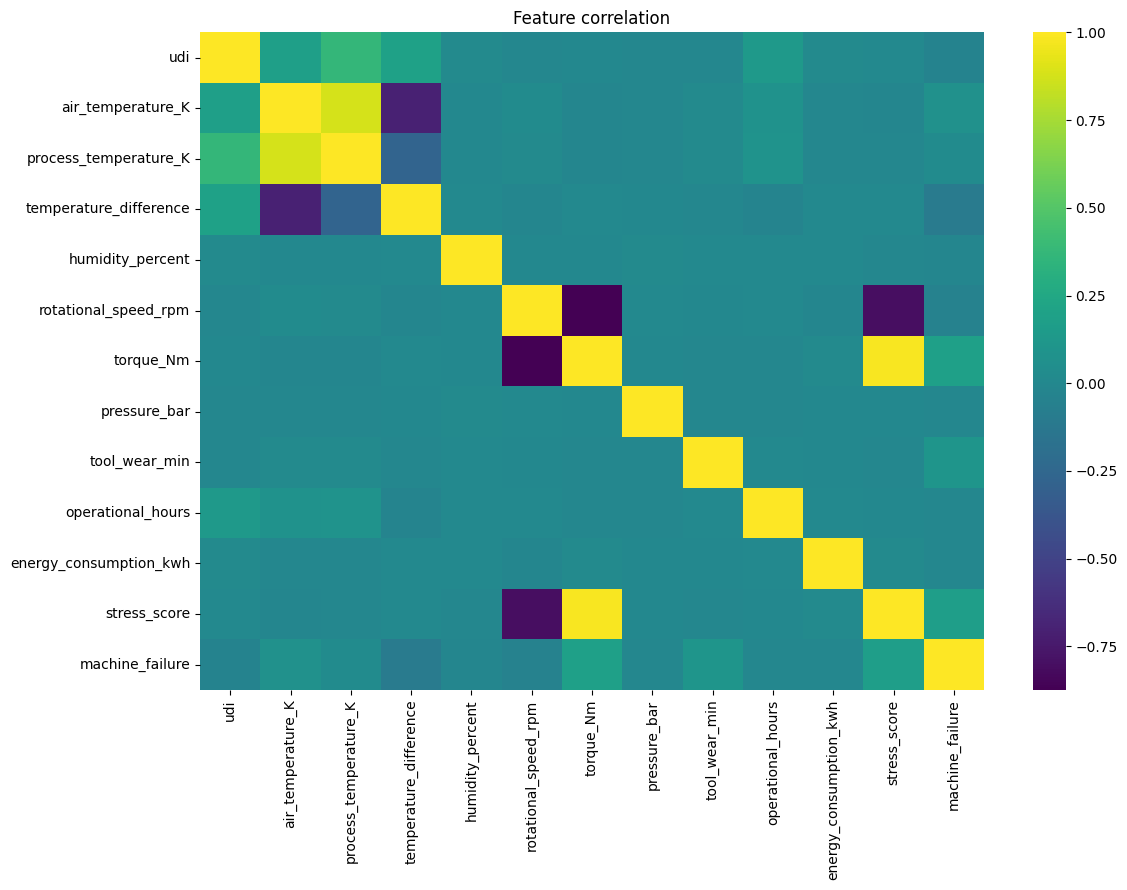

Selected model: RandomForestClassifier
Selected parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Train accuracy: 0.9511
Test accuracy: 0.9452
Train-test gap: 0.0058
CV scores: [np.float64(0.9386), np.float64(0.949), np.float64(0.9362), np.float64(0.9362), np.float64(0.949)]
CV mean: 0.9418
CV std: 0.006


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Load the dataset
path = 'full_realistic_predictive_maintenance_dataset.csv'
data = pd.read_csv(path)

# Quick dataset check
print('Shape:', data.shape)
print('Columns:', list(data.columns))
print('Missing values:\n', data.isnull().sum())

# Clean missing values
clean_data = data.copy()
clean_data['tool_wear_min'] = clean_data['tool_wear_min'].fillna(clean_data['tool_wear_min'].median())
clean_data['vibration_level'] = clean_data['vibration_level'].fillna(clean_data['vibration_level'].mode()[0])
clean_data['maintenance_history'] = clean_data['maintenance_history'].fillna(clean_data['maintenance_history'].mode()[0])

# Simple EDA
print('Failure counts:')
print(clean_data['machine_failure'].value_counts().sort_index())

num_cols = clean_data.select_dtypes(include=['number']).columns.tolist()
print('\nAverage value by failure class:')
print(clean_data.groupby('machine_failure')[num_cols].mean().round(2))

corr_matrix = clean_data[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=False, cmap='viridis')
plt.title('Feature correlation')
plt.tight_layout()
plt.show()

# Feature engineering
vibration_map = {'Low': 1, 'Medium': 2, 'High': 3}
maintenance_map = {'Good': 1, 'Average': 2, 'Poor': 3}

clean_data['temperature_gap'] = clean_data['process_temperature_K'] - clean_data['air_temperature_K']
clean_data['heat_stress_score'] = clean_data['temperature_difference'] * clean_data['torque_Nm']
clean_data['energy_per_hour'] = clean_data['energy_consumption_kwh'] / clean_data['operational_hours'].replace(0, np.nan)
clean_data['wear_rate'] = clean_data['tool_wear_min'] / clean_data['operational_hours'].replace(0, np.nan)
clean_data['vibration_intensity'] = clean_data['vibration_level'].map(vibration_map).fillna(0)
clean_data['maintenance_penalty'] = clean_data['maintenance_history'].map(maintenance_map).fillna(0)
clean_data['energy_per_hour'] = clean_data['energy_per_hour'].fillna(clean_data['energy_per_hour'].median())
clean_data['wear_rate'] = clean_data['wear_rate'].fillna(clean_data['wear_rate'].median())

# Prepare target and features
label_col = 'machine_failure'
feature_cols = [col for col in clean_data.columns if col not in ['udi', 'product_id', 'failure_type', label_col]]

features = clean_data[feature_cols]
labels = clean_data[label_col].astype(int)

numeric_cols = features.select_dtypes(exclude=['object', 'string']).columns.tolist()
categorical_cols = features.select_dtypes(include=['object', 'string']).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ('fill_missing', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('fill_missing', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

model = Pipeline(steps=[
    ('prep', preprocess),
    ('forest', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    ))
])

train_x, test_x, train_y, test_y = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

best_model = model.fit(train_x, train_y)

train_accuracy = accuracy_score(train_y, best_model.predict(train_x))
test_accuracy = accuracy_score(test_y, best_model.predict(test_x))

print('Selected model:', type(best_model.named_steps['forest']).__name__)
print('Selected parameters:', best_model.named_steps['forest'].get_params())
print('Train accuracy:', round(train_accuracy, 4))
print('Test accuracy:', round(test_accuracy, 4))
print('Train-test gap:', round(train_accuracy - test_accuracy, 4))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model,
    features,
    labels,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
print('CV scores:', [round(score, 4) for score in cv_scores])
print('CV mean:', round(cv_scores.mean(), 4))
print('CV std:', round(cv_scores.std(), 4))

Accuracy: 0.9452
Precision: 0.3694
Recall: 0.7838
F1 Score: 0.5022
ROC-AUC: 0.951

Confusion Matrix:
[[1927   99]
 [  16   58]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9918    0.9511    0.9710      2026
           1     0.3694    0.7838    0.5022        74

    accuracy                         0.9452      2100
   macro avg     0.6806    0.8675    0.7366      2100
weighted avg     0.9698    0.9452    0.9545      2100



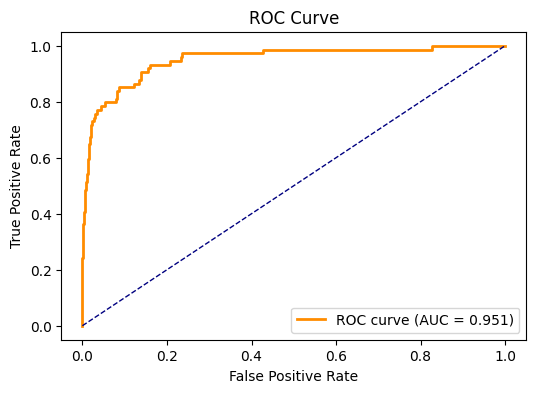


Top 20 Feature Importances:
                     feature  importance
              num__torque_Nm    0.156588
           num__stress_score    0.155214
   num__rotational_speed_rpm    0.152672
      num__heat_stress_score    0.096214
          num__tool_wear_min    0.089624
 num__temperature_difference    0.088746
        num__temperature_gap    0.067234
              num__wear_rate    0.041568
      num__air_temperature_K    0.031899
      num__operational_hours    0.022068
        num__energy_per_hour    0.017270
  num__process_temperature_K    0.012313
 num__energy_consumption_kwh    0.009818
    num__vibration_intensity    0.008888
       num__humidity_percent    0.008474
           num__pressure_bar    0.007345
         cat__machine_type_L    0.003921
    num__maintenance_penalty    0.003111
cat__factory_section_Cooling    0.002106
         cat__machine_type_H    0.001940


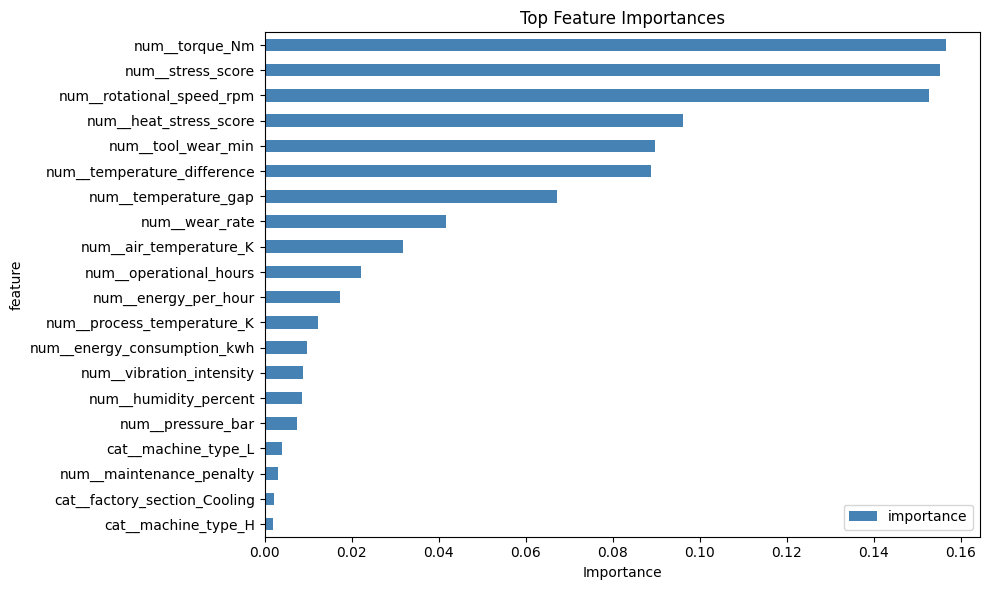

In [3]:
# Make predictions on the holdout set
# Probability of failure is the positive class probability
best_model.fit(train_x, train_y)
y_pred = best_model.predict(test_x)
y_prob = best_model.predict_proba(test_x)[:, 1]

# Metrics
accuracy = accuracy_score(test_y, y_pred)
precision = precision_score(test_y, y_pred, zero_division=0)
recall = recall_score(test_y, y_pred, zero_division=0)
f1 = f1_score(test_y, y_pred, zero_division=0)
roc_auc = roc_auc_score(test_y, y_prob)

print('Accuracy:', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall:', round(recall, 4))
print('F1 Score:', round(f1, 4))
print('ROC-AUC:', round(roc_auc, 4))

print('\nConfusion Matrix:')
print(confusion_matrix(test_y, y_pred))

print('\nClassification Report:')
print(classification_report(test_y, y_pred, digits=4))

# ROC curve
fpr, tpr, thresholds = roc_curve(test_y, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Feature importance from trained model
preprocessor = best_model.named_steps['prep']
classifier = best_model.named_steps['forest']

feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

print('\nTop 20 Feature Importances:')
print(feature_importance_df.to_string(index=False))

feature_importance_df.plot(kind='barh', x='feature', y='importance', color='steelblue', figsize=(10,6))
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top Feature Importances')
plt.tight_layout()
plt.show()


In [4]:
# Example prediction for a new machine
sample_input = pd.DataFrame([
    {
        'machine_type': 'M',
        'factory_section': 'Production',
        'shift': 'Night',
        'air_temperature_K': 302.5,
        'process_temperature_K': 312.0,
        'temperature_difference': 9.5,
        'humidity_percent': 78,
        'rotational_speed_rpm': 1500,
        'torque_Nm': 50,
        'pressure_bar': 4.2,
        'tool_wear_min': 180,
        'vibration_level': 'High',
        'operational_hours': 120,
        'energy_consumption_kwh': 130.5,
        'maintenance_history': 'Average',
        'stress_score': 75.0,
    }
])

# Apply the same feature engineering used in training
vibration_map = {'Low': 1, 'Medium': 2, 'High': 3}
maintenance_map = {'Good': 1, 'Average': 2, 'Poor': 3}

sample_input['temperature_gap'] = sample_input['process_temperature_K'] - sample_input['air_temperature_K']
sample_input['heat_stress_score'] = sample_input['temperature_difference'] * sample_input['torque_Nm']
sample_input['energy_per_hour'] = sample_input['energy_consumption_kwh'] / sample_input['operational_hours'].replace(0, np.nan)
sample_input['wear_rate'] = sample_input['tool_wear_min'] / sample_input['operational_hours'].replace(0, np.nan)
sample_input['vibration_intensity'] = sample_input['vibration_level'].map(vibration_map).fillna(0)
sample_input['maintenance_penalty'] = sample_input['maintenance_history'].map(maintenance_map).fillna(0)
sample_input['energy_per_hour'] = sample_input['energy_per_hour'].fillna(sample_input['energy_per_hour'].median())
sample_input['wear_rate'] = sample_input['wear_rate'].fillna(sample_input['wear_rate'].median())

sample_prob = best_model.predict_proba(sample_input)[0, 1]
sample_pred = best_model.predict(sample_input)[0]

print('Predicted class (0 = safe, 1 = likely failure):', sample_pred)
print('Failure probability:', round(sample_prob, 4))
print('Risk level:', 'HIGH' if sample_prob >= 0.5 else 'LOW')


Predicted class (0 = safe, 1 = likely failure): 0
Failure probability: 0.3451
Risk level: LOW


In [ ]:
%pip install langchain langchain-google-genai langchain-core pydantic

import json
from maintenance_report_generator import build_maintenance_report

sample_record = sample_input.iloc[0].to_dict()
sample_prediction = int(best_model.predict(sample_input)[0])
sample_probability = float(best_model.predict_proba(sample_input)[0, 1])

try:
    maintenance_report = build_maintenance_report(sample_prediction, sample_probability, sample_record)
    print(json.dumps(maintenance_report, indent=2))
except Exception as exc:
    print(f"Maintenance report generation failed: {exc}")


ModuleNotFoundError: No module named 'langchain_core'